     filename  start    end  intensity_pred_kushinada
0  0001_L.wav  0.297  1.781                      3.85
1  0004_L.wav  2.510  3.957                      2.29
2  0006_L.wav  5.093  5.725                      0.76
3  0007_L.wav  6.258  6.988                      1.98
4  0009_L.wav  7.919  9.241                      2.34
     filename  start     end  intensity_pred_kushinada
0  0003_R.wav  0.830   2.188                      2.59
1  0005_R.wav  3.562   5.141                      0.55
2  0008_R.wav  6.317   8.325                      0.85
3  0010_R.wav  8.329   9.362                      3.75
4  0011_R.wav  9.366  15.600                      0.88


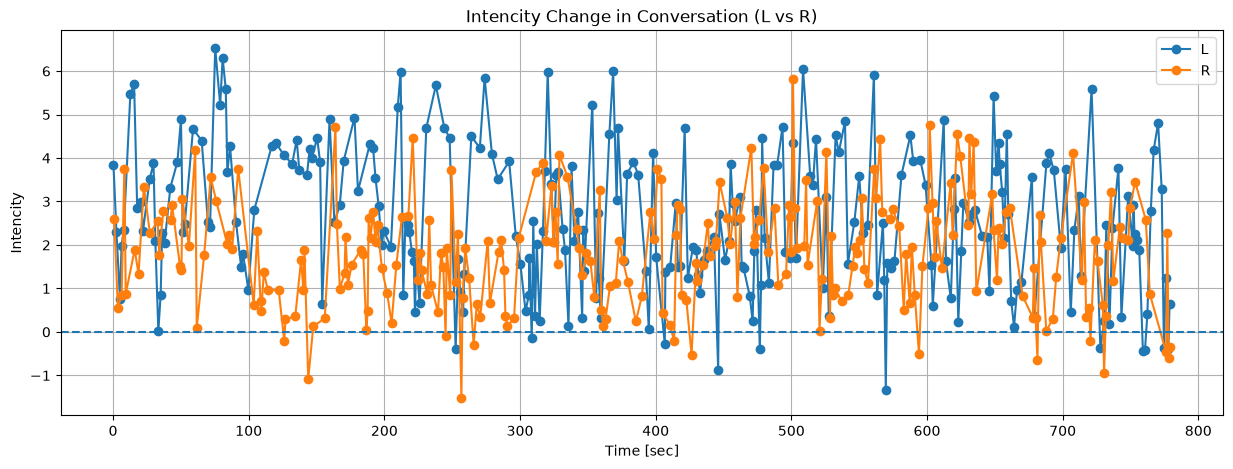

In [2]:
# 成功
import pandas as pd
import matplotlib.pyplot as plt

L_csv = "/home/mitani/CSJ-emo-int_bunseki/0718/0720/LR_bunseki/data/vad_delta_L.csv"
R_csv = "/home/mitani/CSJ-emo-int_bunseki/0718/0720/LR_bunseki/data/vad_delta_R.csv"
seg_csv = "/home/mitani/CSJ-emo-int_bunseki/0718/0720/LR_bunseki/data/Segments/D03F0001/D03F0001_segments.csv"  # 時間情報あり

df_L = pd.read_csv(L_csv)
df_R = pd.read_csv(R_csv)
segments = pd.read_csv(seg_csv)

# ==========================
# filename形式を合わせる
# ==========================

# vad側:
# 0001_L.wav

# segments側:
# 1_L.wav

# 先頭0を除去
df_L["wavfile"] = df_L["filename"].str.lstrip("0")
df_R["wavfile"] = df_R["filename"].str.lstrip("0")


# ==========================
# 時刻情報を追加
# ==========================

df_L = df_L.merge(
    segments[["wavfile","start","end"]],
    on="wavfile",
    how="left"
)


df_R = df_R.merge(
    segments[["wavfile","start","end"]],
    on="wavfile",
    how="left"
)

# ==========================
# 確認
# ==========================

print(df_L[["filename","start","end","intensity_pred_kushinada"]].head())
print(df_R[["filename","start","end","intensity_pred_kushinada"]].head())

# ==========================
# 可視化
# ==========================

plt.figure(figsize=(15,5))


# L
plt.plot(
    df_L["start"],
    df_L["intensity_pred_kushinada"],
    label="L",
    marker="o"
)


# R
plt.plot(
    df_R["start"],
    df_R["intensity_pred_kushinada"],
    label="R",
    marker="o"
)


plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel("Time [sec]")
plt.ylabel("Intencity")

plt.title(
    "Intencity Change in Conversation (L vs R)"
)

plt.legend()
plt.grid()

plt.show()

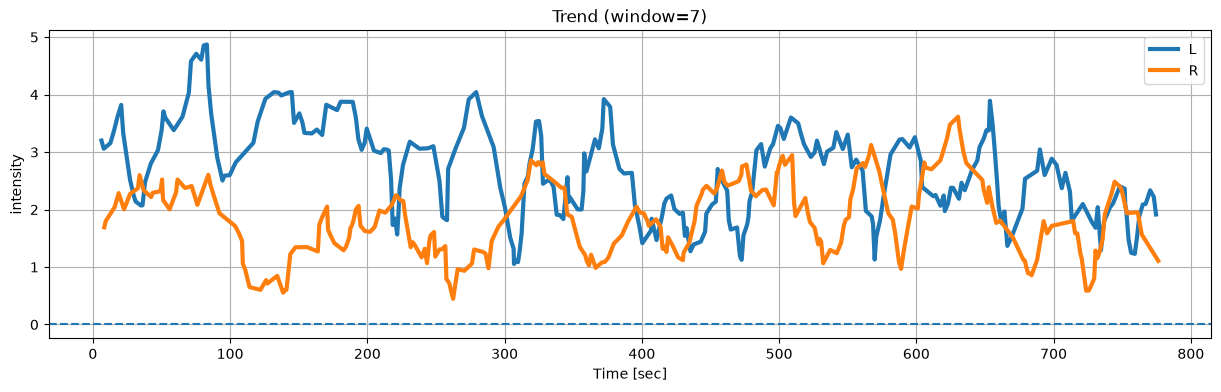

In [3]:
# ==========================
# 可視化（窓サイズ7 移動平均）
# ==========================

window = 7

# 移動平均を追加
df_L["intensity_ma"] = (
    df_L["intensity_pred_kushinada"]
    .rolling(window=window, center=True)    # center=True;未来の発話を使う
    .mean()
)

df_R["intensity_ma"] = (
    df_R["intensity_pred_kushinada"]
    .rolling(window=window, center=True)
    .mean()
)


plt.figure(figsize=(15,4))

# 移動平均
plt.plot(
    df_L["start"],
    df_L["intensity_ma"],
    label="L",
    linewidth=3
)


plt.plot(
    df_R["start"],
    df_R["intensity_ma"],
    label="R",
    linewidth=3
)


plt.axhline(
    0,
    linestyle="--"
)


plt.xlabel("Time [sec]")
plt.ylabel("intensity")

plt.title(
    "Trend (window=7)"
)

plt.legend()
plt.grid()

plt.show()